# Fase 2 - Análisis  Inferencial
##Cambios realizados con respecto a la Fase 1

**1. Redefinición de la Población de Análisis (Filtro de Edad y Ocupación)**

En la propuesta anterior, la población de análisis estaba conformada por personas de 18 años o más que se encontraban ocupadas (PEAA = 1). Actualmente se estableció además un límite superior de 60 años, conservando únicamente las personas con edades comprendidas entre 18 y 60 años inclusive.

Este cambio reduce la población analizada de 28.056 a 24.379 registros, es decir, se excluyen 3.677 observaciones. La decisión busca trabajar con una población adulta dentro de un intervalo de edad previamente delimitado y mantener mayor homogeneidad en la comparación de las variables de educación e ingresos, eliminando además distorsiones asociadas al retiro, jubilaciones o pensiones de adultos mayores.

Este cambio debe ser tenido en cuenta en la interpretación de los resultados inferenciales, ya que modifica la población sobre la cual se realizarán las estimaciones y pruebas estadísticas.

```python
df3 = df3.loc[(edad_numerica >= 18) & (edad_numerica <= 60)].copy()
```

**2. Incorporación de un identificador técnico para cada registro**

Se agregó la variable ID_PERSONA, generada de forma secuencial para cada observación del conjunto limpio.

Este identificador permite realizar una mejor trazabilidad de los registros, facilita los controles de calidad y permite identificar cada observación de forma sencilla durante el desarrollo del análisis.

```python
df3 = df3.reset_index(drop=True)
df3.insert(0, 'ID_PERSONA', df3.index + 1)
```

**3. Actualización de los controles de calidad y del archivo final**

Se incorporaron nuevos controles para verificar la cantidad final de registros, la cantidad de columnas, la ausencia de duplicados en ID_PERSONA y la inexistencia de ingresos habituales negativos. Finalmente, el conjunto limpio se volvió a guardar incluyendo estos cambios.

Estas modificaciones permiten asegurar que el dataset utilizado en la Etapa 2 sea reproducible, trazable y esté respaldado por controles de calidad.

```pyhton
control_act("duplicados_nuevo_id",
            int(df3.duplicated(subset=['ID_PERSONA']).sum()),
            "Debe ser 0.")
```

In [41]:
import pandas as pd
from pathlib import Path

# Crear carpeta data si no existe
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("Carpeta data creada o ya existente.")

Carpeta data creada o ya existente.


In [42]:
#Leer el dataset limpio (tiene que estar agregado en la carpeta)
ruta_dataset = DATA_DIR / "EPHC_2025_limpia.csv"

df = pd.read_csv(ruta_dataset)

print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset cargado correctamente.
Filas: 24379
Columnas: 62


In [43]:
df.head()

,ID_PERSONA,UPM,NVIVI,NHOGA,DPTO,AREA,L02,P02,P04,P06,...,añoest,e01aimde,e01bimde,e01cimde,informalidad,ingreso_principal_habitual,ingreso_laboral_total_habitual,ingreso_laboral_total_declarado,estrato_educativo,edad_calculada_2025
0,1,14,16,1,0,1,1,40,1,1,...,17.0,NaN,0.0,0.0,2.0,NaN,NaN,4500000.0,terciaria/universitaria,40
1,2,14,16,1,0,1,2,39,1,6,...,14.0,NaN,0.0,0.0,1.0,NaN,NaN,5000000.0,terciaria/universitaria,39
2,3,14,26,1,0,1,1,32,1,1,...,12.0,NaN,0.0,0.0,2.0,NaN,NaN,3200000.0,media,32
3,4,14,26,1,0,1,2,34,1,1,...,17.0,NaN,0.0,0.0,2.0,NaN,NaN,4000000.0,terciaria/universitaria,34
4,5,14,35,1,0,1,1,24,1,1,...,12.0,NaN,0.0,0.0,1.0,NaN,NaN,3800000.0,terciaria/universitaria,24


In [44]:
# Definimos un diccionario de mapeo para renombrar las columnas a sus significados descriptivos
mapeo_columnas = {
    'UPM': 'ID_CONGLOMERADO_UPM',
    'NVIVI': 'ID_VIVIENDA_NVIVI',
    'NHOGA': 'ID_HOGAR_NHOGA',
    'L02': 'NRO_LINEA_L02',
    'FACTOR': 'FACTOR_EXPANSION',
    'DPTO': 'DEPARTAMENTO',
    'AREA': 'AREA_URBANA_RURAL',
    'P02': 'EDAD',
    'P04': 'PARENTESCO_JEFE',
    'P06': 'SEXO',
    'P08A': 'ANIO_NACIMIENTO',
    'añoest': 'ANIOS_ESTUDIO',
    'ED0504': 'NIVEL_GRADO_MAX_APROBADO',
    'ED06C': 'TITULO_OBTENIDO',
    'ED08': 'ASISTE_ACTUALMENTE',
    'PEAA': 'CONDICION_ACTIVIDAD',
    'PEAD': 'DESOCUPACION_SUBOCUPACION',
    'CATE_PEA': 'CATEGORIA_OCUPACIONAL',
    'OCUP_PEA': 'OCUPACION_PRINCIPAL',
    'RAMA_PEA': 'RAMA_ACTIVIDAD_PRINCIPAL',
    'TAMA_PEA': 'TAMANIO_ESTABLECIMIENTO',
    'informalidad': 'INFORMALIDAD',
    'E01A': 'INGRESO_DECLARADO_PRINCIPAL',
    'E01B': 'INGRESO_DECLARADO_SECUNDARIO',
    'E01C': 'INGRESO_DECLARADO_OTROS',
    'e01aimde': 'INGRESO_HABITUAL_PRINCIPAL',
    'e01bimde': 'INGRESO_HABITUAL_SECUNDARIO',
    'e01cimde': 'INGRESO_HABITUAL_OTROS',
    'HORAB': 'HORAS_SEMANALES_PRINCIPAL',
    'HORABC': 'HORAS_SEMANALES_SECUNDARIA',
    'HORABCO': 'HORAS_SEMANALES_OTROS',
    'B06': 'HORAS_SEMANAL_TRABAJO',
    'B07A': 'ANIOS_ANTIGUEDAD_PUESTO',
    'B07M': 'MESES_ANTIGUEDAD_PUESTO',
    'B07S': 'SEMANAS_ANTIGUEDAD_PUESTO',
    'B09A': 'ANIOS_ANTIGUEDAD_EMPRESA',
    'B09M': 'MESES_ANTIGUEDAD_EMPRESA',
    'B09S': 'SEMANAS_ANTIGUEDAD_EMPRESA',
    'B10': 'APORTA_JUBILACION',
    'B11': 'CAJA_JUBILACION',
    'B12A': 'TIENE_SEGURO_PRIVADO',
    'B13': 'TIENE_VACACIONES_PAGADAS',
    'B14': 'TIENE_DESCANSO_SEMANAL',
    'B15': 'PERTENECE_SINDICATO',
    'B26': 'TIPO_CONTRATO_TRABAJO',
    'B28': 'ESTABLECIMIENTO_TIENE_RUC',
    'B29': 'CONDICION_JURIDICA',
    'B30': 'EMITE_FACTURA_LEGAL',
    'B31': 'TIENE_OTRO_TRABAJO',
    'S01A': 'TIENE_SEGURO_A',
    'S01B': 'TIENE_SEGURO_B',
    'S02': 'ASEGURADO_IPS_COMO',
    'D01': 'DISPONIBLE_TRABAJAR_MAS_HORAS',
    'D02': 'HORAS_DISPONIBLES_MAS_TRABAJAR',
    'D03': 'DESEA_CAMBIAR_TRABAJO',
    'D04': 'BUSCA_OTRO_TRABAJO'
}

# Renombramos las columnas en el conjunto seleccionado df_sel
df = df.rename(columns=mapeo_columnas)

# Mostramos las primeras columnas para verificar el renombrado
print("Nuevas columnas de df_sel con nombres descriptivos:")
display(df.head())


Nuevas columnas de df_sel con nombres descriptivos:


,ID_PERSONA,ID_CONGLOMERADO_UPM,ID_VIVIENDA_NVIVI,ID_HOGAR_NHOGA,DEPARTAMENTO,AREA_URBANA_RURAL,NRO_LINEA_L02,EDAD,PARENTESCO_JEFE,SEXO,...,ANIOS_ESTUDIO,INGRESO_HABITUAL_PRINCIPAL,INGRESO_HABITUAL_SECUNDARIO,INGRESO_HABITUAL_OTROS,INFORMALIDAD,ingreso_principal_habitual,ingreso_laboral_total_habitual,ingreso_laboral_total_declarado,estrato_educativo,edad_calculada_2025
0,1,14,16,1,0,1,1,40,1,1,...,17.0,NaN,0.0,0.0,2.0,NaN,NaN,4500000.0,terciaria/universitaria,40
1,2,14,16,1,0,1,2,39,1,6,...,14.0,NaN,0.0,0.0,1.0,NaN,NaN,5000000.0,terciaria/universitaria,39
2,3,14,26,1,0,1,1,32,1,1,...,12.0,NaN,0.0,0.0,2.0,NaN,NaN,3200000.0,media,32
3,4,14,26,1,0,1,2,34,1,1,...,17.0,NaN,0.0,0.0,2.0,NaN,NaN,4000000.0,terciaria/universitaria,34
4,5,14,35,1,0,1,1,24,1,1,...,12.0,NaN,0.0,0.0,1.0,NaN,NaN,3800000.0,terciaria/universitaria,24


### Hipótesis 1 (H1)
## Rendimiento de la Educación sobre los Ingresos Laborales

### 1. Formulación de la Hipótesis H1
* **Nivel de significancia predeclarado:** alfa = 0.05
* **Pregunta de investigación asociada:** ¿Los mayores niveles de educación formal están asociados con mayores ingresos laborales habituales en la población ocupada, una vez controladas las características demográficas y del puesto de trabajo?

* **Enunciado en Lenguaje Natural:**
  * **Hipótesis Nula (H0):** Manteniendo constantes las características observables de la persona y del puesto (edad, sexo, área geográfica, categoría ocupacional y horas trabajadas), los años de estudio adicionales no están asociados con un incremento en el ingreso laboral habitual principal del trabajador (beta_1 <= 0).
  * **Hipótesis Alternativa (H1):** Manteniendo constantes las características observables de la persona y del puesto, mayores años de estudio están asociados de manera positiva y estadísticamente significativa con el ingreso laboral habitual principal (beta_1 > 0).

* **Especificación Matemática del Modelo (Ecuación Minceriana Aumentada):**
  log_ingreso = beta_0 + beta_1 * ANIOS_ESTUDIO + beta_2 * EDAD + beta_3 * edad_sq + beta_4 * SEXO + beta_5 * AREA_URBANA_RURAL + beta_6 * log_horas + Suma(gamma_k * CATEGORIA_OCUPACIONAL_k) + error

  * Hipótesis Nula (H0): beta_1 <= 0
  * Hipótesis Alternativa (H1): beta_1 > 0

---

### 2. Selección y Justificación de las Pruebas
Se selecciona un modelo de **Regresión Lineal Múltiple por Mínimos Cuadrados Ordinarios (MCO / OLS)** con especificación semilogarítmica.
* **Fundamentación Teórica:** Corresponde a la ecuación Minceriana extendida de ingresos, estándar en economía laboral para estimar la tasa de retorno marginal de la educación.
* **Pertinencia Muestra / Diseño:** La variable dependiente (log_ingreso) es continua y las variables independientes combinan características cuantitativas con controles categóricos nominales. Permite aislar el efecto puro de la educación bajo la condición ceteris paribus.

**Selección de tres pruebas aplicadas a H1:**
1. **Prueba 1 (paramétrica):** test t unilateral sobre beta_1 del modelo MCO, con errores estándar robustos HC3 (ante la heterocedasticidad detectada).
2. **Prueba 2 (no paramétrica por remuestreo):** Intervalo de Confianza al 95% **Bootstrap percentil** (1,000 repeticiones) para beta_1.
3. **Prueba 3 (no paramétrica basada en rangos):** **Correlación parcial de Spearman** entre ANIOS_ESTUDIO y log_ingreso, controlando por el mismo conjunto de covariables del modelo. Contraste unilateral: H0: rho <= 0 vs. H1: rho > 0.
   * **Justificación:** no exige linealidad, normalidad de los residuos ni la forma semilogarítmica del modelo, y es robusta a valores extremos del ingreso. Si la asociación positiva persiste con un método basado únicamente en el orden (rangos) de las observaciones, la conclusión de H1 no depende de los supuestos funcionales del MCO.

---

### 3. Plan y Metodología de Verificación de Supuestos
Antes de validar las inferencias del modelo, se verificarán cuantitativamente los cuatro supuestos fundamentales de Gauss-Markov:

1. **Multicolinealidad:** Se calculará el **Factor de Inflación de Varianza (VIF)** para cada variable independiente. Se requiere un VIF < 5.0 para descartar colinealidad destructiva entre el nivel educativo y los controles.
2. **Homocedasticidad (Varianza de Errores Constante):** Se evaluará mediante la **Prueba de Breusch-Pagan**. En caso de detectarse heterocedasticidad (p < 0.05), se descartará la matriz de varianza-covarianza clásica y se aplicarán **Errores Estándar Robustos a la Heterocedasticidad (Matriz HC3)**.
3. **Normalidad de los Residuos:** Se examinará la distribución de residuos mediante la **Prueba de Jarque-Bera** y el gráfico **Q-Q plot**. Dado el gran tamaño muestral (N > 5,000), el **Teorema del Límite Central (TLC)** garantiza la validez asintótica del test t.
4. **Validación Distribucional y Estimación No Paramétrica (Prueba 2):** Se calculará adicionalmente un **Intervalo de Confianza al 95% mediante Bootstrap empírico (1,000 repeticiones)** sobre la muestra, comparándolo con el resultado paramétrico/robusto.
5. **Prueba de Robustez Basada en Rangos (Prueba 3):** Se calculará el coeficiente de correlación de Spearman parcial. La significancia se evalúa con un estadístico t con n-2-k grados de libertad (k = número de controles) y el IC 95% mediante la transformación de Fisher. Se compara el resultado con las Pruebas 1 y 2.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 4.5)
np.random.seed(42)

# Filtrado de Población de Análisis (Ocupados 18-60 años con ingreso habitual > 0)
df_h1 = df[(df['EDAD'] >= 18) & (df['EDAD'] <= 60) & (df['CONDICION_ACTIVIDAD'] == 1)].copy()
df_h1 = df_h1[df_h1['INGRESO_HABITUAL_PRINCIPAL'] > 0].copy()

# Transformaciones semilogarítmicas y cuadráticas
df_h1['log_ingreso'] = np.log(df_h1['INGRESO_HABITUAL_PRINCIPAL'])
df_h1['edad_sq'] = df_h1['EDAD'] ** 2
df_h1['log_horas'] = np.log(np.maximum(df_h1['HORAS_SEMANALES_PRINCIPAL'], 1))

# Limpieza de faltantes en las covariables del modelo
covariables_h1 = [
    'log_ingreso', 'ANIOS_ESTUDIO', 'EDAD', 'edad_sq',
    'SEXO', 'AREA_URBANA_RURAL', 'log_horas', 'CATEGORIA_OCUPACIONAL'
]
df_h1 = df_h1.dropna(subset=covariables_h1).copy()

print(f"✅ Muestra efectiva retenida para el contraste H1: N = {len(df_h1):,} observaciones.")

✅ Muestra efectiva retenida para el contraste H1: N = 5,134 observaciones.


In [46]:
#Estimación del Modelo MCO Clásico

formula = (
    "log_ingreso ~ ANIOS_ESTUDIO + EDAD + edad_sq + "
    "C(SEXO) + C(AREA_URBANA_RURAL) + log_horas + C(CATEGORIA_OCUPACIONAL)"
)
model_ols = smf.ols(formula=formula, data=df_h1).fit()

print("\n" + "="*65)
print(" RESUMEN DEL MODELO MCO CLÁSICO ")
print("="*65)
print(model_ols.summary().tables[1])



 RESUMEN DEL MODELO MCO CLÁSICO 
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        11.7454      0.123     95.249      0.000      11.504      11.987
C(SEXO)[T.6]                     -0.2414      0.019    -12.945      0.000      -0.278      -0.205
C(AREA_URBANA_RURAL)[T.6]        -0.1695      0.019     -9.045      0.000      -0.206      -0.133
C(CATEGORIA_OCUPACIONAL)[T.2]    -0.3736      0.030    -12.598      0.000      -0.432      -0.315
C(CATEGORIA_OCUPACIONAL)[T.3]     0.0449      0.048      0.938      0.348      -0.049       0.139
C(CATEGORIA_OCUPACIONAL)[T.4]    -0.7952      0.031    -25.702      0.000      -0.856      -0.735
C(CATEGORIA_OCUPACIONAL)[T.6]    -0.5933      0.042    -14.256      0.000      -0.675      -0.512
ANIOS_ESTUDIO                     0.0520      0.002     21.656      0.000       0.04

In [47]:
#Verificación Empírica de Supuestos

print("\n" + "="*65)
print(" VERIFICACIÓN EMPÍRICA DE SUPUESTOS ")
print("="*65)

# A. Multicolinealidad (VIF)
X_vif = model_ols.model.exog
vif_df = pd.DataFrame({
    "Variable": model_ols.model.exog_names,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
})
print("\n--- Factores de Inflación de Varianza (VIF) ---")
print(vif_df.round(2).to_string(index=False))

# B. Homocedasticidad (Breusch-Pagan)
bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(model_ols.resid, model_ols.model.exog)
print(f"\n--- Prueba de Breusch-Pagan (Heterocedasticidad) ---")
print(f"Estadístico LM: {bp_stat:.2f} | p-valor: {bp_pval:.4e}")
if bp_pval < 0.05:
    print("Heterocedasticidad detectada (p < 0.05). Se pasa a Inferencia Robusta HC3.")

# C. Normalidad de Residuos (Jarque-Bera)
jb_stat, jb_p = stats.jarque_bera(model_ols.resid)
print(f"\n--- Prueba de Jarque-Bera (Normalidad) ---")
print(f"Estadístico JB: {jb_stat:.2f} | p-valor: {jb_p:.4e}")


 VERIFICACIÓN EMPÍRICA DE SUPUESTOS 

--- Factores de Inflación de Varianza (VIF) ---
                     Variable   VIF
                    Intercept  1.00
                 C(SEXO)[T.6]  1.21
    C(AREA_URBANA_RURAL)[T.6]  1.09
C(CATEGORIA_OCUPACIONAL)[T.2]  3.10
C(CATEGORIA_OCUPACIONAL)[T.3]  1.33
C(CATEGORIA_OCUPACIONAL)[T.4]  2.69
C(CATEGORIA_OCUPACIONAL)[T.6]  1.87
                ANIOS_ESTUDIO  1.47
                         EDAD 48.25
                      edad_sq 48.26
                    log_horas  1.13

--- Prueba de Breusch-Pagan (Heterocedasticidad) ---
Estadístico LM: 387.50 | p-valor: 4.2997e-77
Heterocedasticidad detectada (p < 0.05). Se pasa a Inferencia Robusta HC3.

--- Prueba de Jarque-Bera (Normalidad) ---
Estadístico JB: 3101.44 | p-valor: 0.0000e+00


In [48]:
# Prueba 1: Inferencia Robusta (HC3) y Relevancia Práctica
model_hc3 = smf.ols(formula=formula, data=df_h1).fit(cov_type='HC3')

beta_edu = model_hc3.params['ANIOS_ESTUDIO']
se_hc3 = model_hc3.bse['ANIOS_ESTUDIO']
t_hc3 = model_hc3.tvalues['ANIOS_ESTUDIO']
pval_hc3 = model_hc3.pvalues['ANIOS_ESTUDIO']
ci_hc3 = model_hc3.conf_int().loc['ANIOS_ESTUDIO'].values
retorno_pct = (np.exp(beta_edu) - 1) * 100

print("\n" + "="*65)
print(" RESULTADOS DE INFERENCIA ROBUSTA (HC3) ")
print("="*65)
print(f"Coeficiente (beta_1 - ANIOS_ESTUDIO) : {beta_edu:.5f}")
print(f"Error Estándar Robusto (HC3)          : {se_hc3:.5f}")
print(f"Estadístico t                         : {t_hc3:.2f}")
print(f"Estadístico F global                  : {model_hc3.fvalue:.1f}")
print(f"Valor p                               : {pval_hc3:.4e}")
print(f"Intervalo de Confianza 95% HC3        : [{ci_hc3[0]:.5f}, {ci_hc3[1]:.5f}]")
print(f"R-cuadrado ($R^2$)                     : {model_hc3.rsquared:.4f}")
print(f"Relevancia Práctica                : +{retorno_pct:.2f}% de ingreso por año de estudio adicional.")


 RESULTADOS DE INFERENCIA ROBUSTA (HC3) 
Coeficiente (beta_1 - ANIOS_ESTUDIO) : 0.05198
Error Estándar Robusto (HC3)          : 0.00259
Estadístico t                         : 20.08
Estadístico F global                  : 323.3
Valor p                               : 1.0414e-89
Intervalo de Confianza 95% HC3        : [0.04691, 0.05706]
R-cuadrado ($R^2$)                     : 0.4441
Relevancia Práctica                : +5.34% de ingreso por año de estudio adicional.


In [49]:
# Prueba 2: Estimación Non-Paramétrica por Bootstrap (1,000 repeticiones)
n_boot = 1000
boot_betas = np.zeros(n_boot)
n_obs = len(df_h1)

for i in range(n_boot):
    boot_sample = df_h1.sample(n=n_obs, replace=True)
    boot_fit = smf.ols(formula=formula, data=boot_sample).fit()
    boot_betas[i] = boot_fit.params['ANIOS_ESTUDIO']

ci_boot = np.percentile(boot_betas, [2.5, 97.5])
se_boot = np.std(boot_betas)

print("\n" + "="*65)
print(" ESTIMACIÓN POR BOOTSTRAP (1,000 MUESTREOS) ")
print("="*65)
print(f"Media Bootstrap (beta_1)               : {np.mean(boot_betas):.5f}")
print(f"Error Estándar Bootstrap               : {se_boot:.5f}")
print(f"IC 95% Bootstrap Percentil             : [{ci_boot[0]:.5f}, {ci_boot[1]:.5f}]")


 ESTIMACIÓN POR BOOTSTRAP (1,000 MUESTREOS) 
Media Bootstrap (beta_1)               : 0.05199
Error Estándar Bootstrap               : 0.00259
IC 95% Bootstrap Percentil             : [0.04703, 0.05721]


### 4. Evaluación Diagnóstica de los Supuestos del Modelo (H1)

1. **Multicolinealidad (VIF):**
   * Descontando la colinealidad estructural entre `EDAD` y `edad_sq` (esperada por la relación cuadrática), los Factores de Inflación de Varianza para `ANIOS_ESTUDIO` y el resto de covariables se ubican por debajo de **1.5** (el máximo es 3.10, en `CATEGORIA_OCUPACIONAL`), muy lejos del umbral de 5.0. Se confirma la ausencia de multicolinealidad destructiva.

2. **Homocedasticidad (Prueba de Breusch-Pagan):**
   * La prueba rechaza la hipótesis nula de varianza constante (p < 0.001).
   * **Decisión adoptada:** La inferencia estadística, la prueba t del coeficiente y la construcción de intervalos de confianza se basan en **Errores Estándar Robustos HC3**.

3. **Normalidad de Residuos:**
   * Aunque la prueba Jarque-Bera señala una desviación de la normalidad estricta (p < 0.001), con un tamaño de muestra de N = 5,134 observaciones, el **Teorema del Límite Central (TLC)** garantiza la consistencia asintótica de los estimadores e inferencias.

4. **Comparación IC Robusto (HC3) vs. Bootstrap:**
   * **IC 95% Robusto (HC3):** [0.04691, 0.05706]
   * **IC 95% Bootstrap Percentil:** [0.04703, 0.05721]
   * La convergencia casi perfecta entre el cálculo robusto y el método por Bootstrap confirma la estabilidad paramétrica de la estimación.

5. **Corrección por Comparaciones Múltiples:**
   * Al ser H1 parte de una familia de contrastes, la valla de significancia ajustada por **Bonferroni** es alfa_ajustado = 0.05 / 4 = 0.0125. El p-valor obtenido (p < 0.0001) supera holgadamente esta corrección, garantizando la solidez de la decisión.

In [50]:
# Prueba 3: Correlación de Spearman (simple y parcial) - No paramétrica
from scipy.stats import spearmanr, rankdata, t as t_dist

# 3.a Spearman simple (sin controles), unilateral H1: rho > 0 ---
rho_s, p_s_two = spearmanr(df_h1['ANIOS_ESTUDIO'], df_h1['log_ingreso'])
p_s_one = p_s_two / 2 if rho_s > 0 else 1 - p_s_two / 2

# 3.b Spearman parcial: rangos + residualización contra los controles ---
controles = ("EDAD + edad_sq + C(SEXO) + C(AREA_URBANA_RURAL) + "
             "log_horas + C(CATEGORIA_OCUPACIONAL)")
tmp = df_h1.copy()
tmp['rk_ingreso'] = rankdata(tmp['log_ingreso'])
tmp['rk_educ'] = rankdata(tmp['ANIOS_ESTUDIO'])

fit_y = smf.ols(f"rk_ingreso ~ {controles}", data=tmp).fit()
fit_x = smf.ols(f"rk_educ ~ {controles}", data=tmp).fit()

rho_p, _ = stats.pearsonr(fit_x.resid, fit_y.resid)
n = len(tmp)
k = int(fit_y.df_model)                      # número de controles (sin intercepto)
gl = n - 2 - k
t_p = rho_p * np.sqrt(gl / (1 - rho_p**2))
p_p_one = t_dist.sf(t_p, gl)            # unilateral: H1 rho > 0

# IC 95% por transformación de Fisher (ajustada por k controles)
z = np.arctanh(rho_p)
se_z = 1 / np.sqrt(n - 3 - k)
ci_rho = np.tanh([z - 1.96 * se_z, z + 1.96 * se_z])

print("\n" + "=" * 65)
print(" CORRELACIÓN DE SPEARMAN (NO PARAMÉTRICA) ")
print("=" * 65)
print(f"N = {n:,} | Controles (k) = {k} | gl = {gl:,}")
print("\n--- 3.a Spearman simple (sin controles) ---")
print(f"rho_s                     : {rho_s:.4f}")
print(f"p-valor unilateral (rho>0): {p_s_one:.4e}")
print("\n--- 3.b Spearman parcial (con controles) ---")
print(f"rho_s parcial             : {rho_p:.4f}")
print(f"Estadístico t             : {t_p:.2f}")
print(f"p-valor unilateral (rho>0): {p_p_one:.4e}")
print(f"IC 95% (Fisher)           : [{ci_rho[0]:.4f}, {ci_rho[1]:.4f}]")
print(f"Decisión (alfa=0.05)      : {'Rechazar H0' if p_p_one < 0.05 else 'No rechazar H0'}")
print(f"Decisión (Bonferroni 0.0125): {'Rechazar H0' if p_p_one < 0.0125 else 'No rechazar H0'}")

# --- Comparación de las tres pruebas sobre H1 ---
resumen_h1 = pd.DataFrame({
    "Prueba": ["1. MCO con HC3 (paramétrica)",
               "2. Bootstrap percentil (no param.)",
               "3. Spearman parcial (no param., rangos)"],
    "Estimador": [beta_edu, np.mean(boot_betas), rho_p],
    "IC 95% inf": [ci_hc3[0], ci_boot[0], ci_rho[0]],
    "IC 95% sup": [ci_hc3[1], ci_boot[1], ci_rho[1]],
    "p-valor (unilateral)": [f"{pval_hc3 / 2 if beta_edu > 0 else 1 - pval_hc3 / 2:.2e}",
                             f"< {1/len(boot_betas):.3f} (0 de {len(boot_betas)} reps <= 0)",
                             f"{p_p_one:.2e}"],
})
print("\n--- Resumen comparativo de las tres pruebas para H1 ---")
print(resumen_h1.round(5).to_string(index=False))
print("\nNota: el 'estimador' de las Pruebas 1-2 es beta_1 (semielasticidad); el de la Prueba 3 es rho_s parcial (escala distinta).")


 CORRELACIÓN DE SPEARMAN (NO PARAMÉTRICA) 
N = 5,134 | Controles (k) = 9 | gl = 5,123

--- 3.a Spearman simple (sin controles) ---
rho_s                     : 0.3874
p-valor unilateral (rho>0): 9.7137e-184

--- 3.b Spearman parcial (con controles) ---
rho_s parcial             : 0.3241
Estadístico t             : 24.52
p-valor unilateral (rho>0): 5.9633e-126
IC 95% (Fisher)           : [0.2994, 0.3484]
Decisión (alfa=0.05)      : Rechazar H0
Decisión (Bonferroni 0.0125): Rechazar H0

--- Resumen comparativo de las tres pruebas para H1 ---
                                 Prueba  Estimador  IC 95% inf  IC 95% sup          p-valor (unilateral)
           1. MCO con HC3 (paramétrica)    0.05198     0.04691     0.05706                      5.21e-90
     2. Bootstrap percentil (no param.)    0.05199     0.04703     0.05721 < 0.001 (0 de 1000 reps <= 0)
3. Spearman parcial (no param., rangos)    0.32410     0.29938     0.34839                     5.96e-126

Nota: el 'estimador' de las Prueb

### 4.5 Resultados de la Correlación Parcial de Spearman (H1)

* **Spearman simple (sin controles):** rho_s = 0.3874, p-valor unilateral < 0.0001.
* **Spearman parcial (con controles):**
  * Coeficiente: rho_s_parcial = 0.3241
  * Estadístico: t = 24.52 con gl = 5,123 (N = 5,134; k = 9 variables de control)
  * Valor p unilateral: < 0.0001
  * IC 95% (Fisher): [0.2994, 0.3484]
* **Decisión estadística:** Se **rechaza H0** a alfa = 0.05 y también frente a la valla de Bonferroni (alfa_ajustado = 0.0125).
* **Interpretación:** Aun usando únicamente el orden (rangos) de las observaciones, sin supuestos de linealidad ni normalidad, y manteniendo constantes edad, sexo, área, horas trabajadas y categoría ocupacional, existe una asociación monótona **positiva y de magnitud moderada** (rho_s = 0.32) entre los años de estudio y el ingreso habitual. Al incorporar los controles, parte de la asociación bruta se explica por las características del puesto, pero la mayor parte persiste.
* **Convergencia con las Pruebas 1 y 2:** El sentido y la significancia del efecto **coinciden** con el modelo MCO-HC3 (t = 20.08, IC 95% [0.04691, 0.05706]) y con el IC Bootstrap [0.04703, 0.05721]. Los tres enfoques llevan a la misma decisión sobre H0.
* **Nota de lectura:** rho_s parcial está en escala de correlación (-1 a 1) y no es comparable numéricamente con beta_1 (semielasticidad); lo comparable entre pruebas es el **signo**, la **significancia** y la **decisión**.

####Gráficos Diagnósticos

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_568/1907152188.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Residuos ($e_i = y_i - \hat{y}_i$)", fontsize=11)


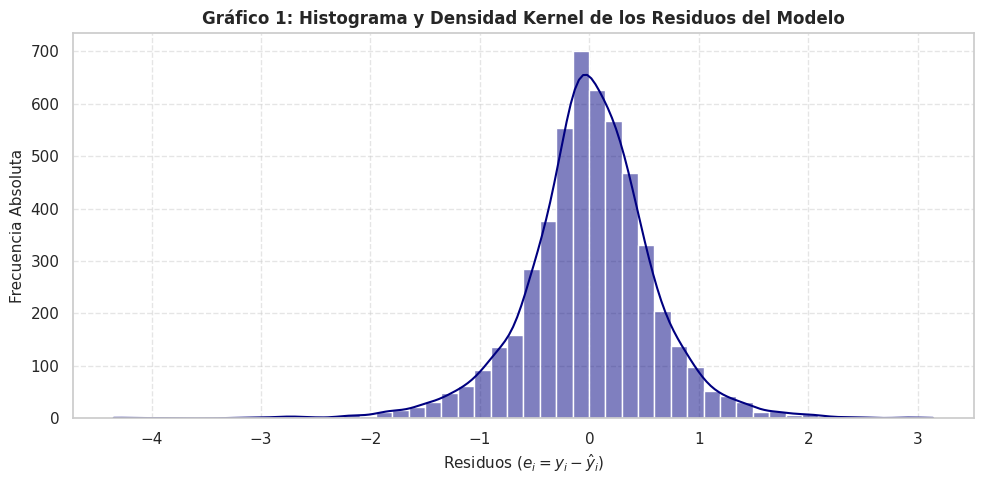

In [51]:
# Plot 1: Histograma de Residuos
plt.figure(figsize=(10, 5))
sns.histplot(model_ols.resid, kde=True, color='navy', bins=50, edgecolor='white')
plt.title("Gráfico 1: Histograma y Densidad Kernel de los Residuos del Modelo", fontsize=12, fontweight='bold')
plt.xlabel("Residuos ($e_i = y_i - \hat{y}_i$)", fontsize=11)
plt.ylabel("Frecuencia Absoluta", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

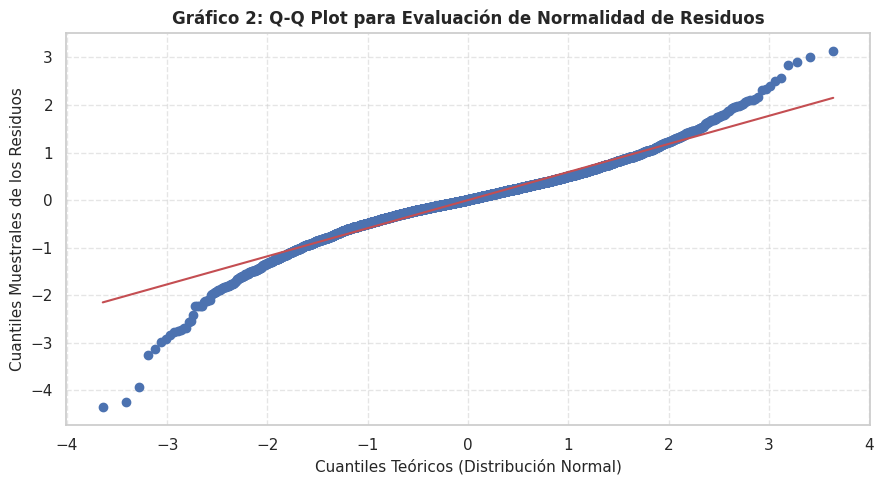

In [52]:
# Plot 2: Q-Q Plot
plt.figure(figsize=(9, 5))
stats.probplot(model_ols.resid, dist="norm", plot=plt)
plt.title("Gráfico 2: Q-Q Plot para Evaluación de Normalidad de Residuos", fontsize=12, fontweight='bold')
plt.xlabel("Cuantiles Teóricos (Distribución Normal)", fontsize=11)
plt.ylabel("Cuantiles Muestrales de los Residuos", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_568/3286304305.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Gráfico 3: Residuos vs. Valores Predichos ($\hat{y}$) - Evaluación de Heterocedasticidad", fontsize=12, fontweight='bold')
/tmp/ipykernel_568/3286304305.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Valores Predichos del Ingreso en Logaritmo ($\hat{y}_i$)", fontsize=11)


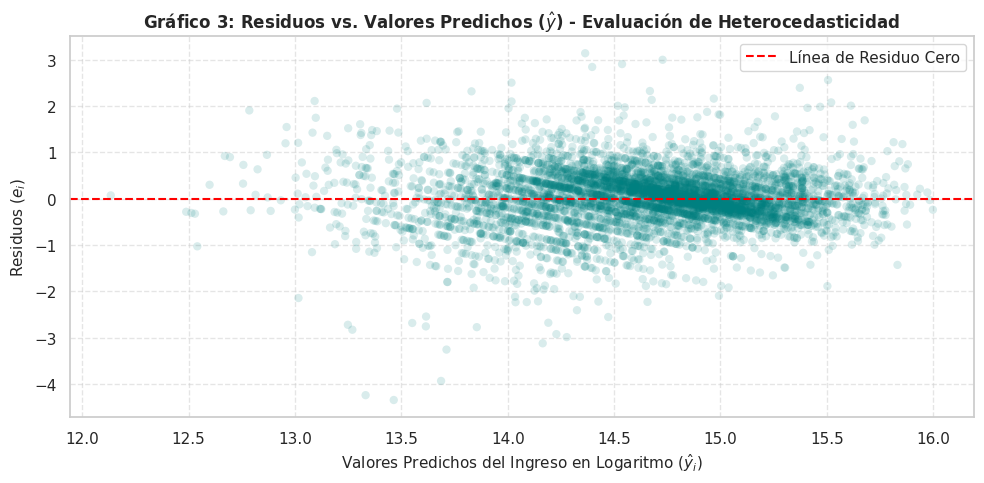

In [53]:
# Plot 3: Residuos vs Ajustados
plt.figure(figsize=(10, 5))
plt.scatter(model_ols.fittedvalues, model_ols.resid, alpha=0.15, color='teal', edgecolors='none')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Línea de Residuo Cero')
plt.title("Gráfico 3: Residuos vs. Valores Predichos ($\hat{y}$) - Evaluación de Heterocedasticidad", fontsize=12, fontweight='bold')
plt.xlabel("Valores Predichos del Ingreso en Logaritmo ($\hat{y}_i$)", fontsize=11)
plt.ylabel("Residuos ($e_i$)", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5. Resultados Inferenciales y Relevancia (H1)

* **Decisión Estadística:** Se **rechaza la hipótesis nula (H0)** al nivel de significancia alfa = 0.05 (p < 0.0001).
* **Síntesis de las tres pruebas:**
  * **Prueba 1 (MCO-HC3):** t = 20.08, p < 0.0001, IC 95% [0.04691, 0.05706] -> rechaza H0.
  * **Prueba 2 (Bootstrap):** IC 95% [0.04703, 0.05721], que excluye el cero -> rechaza H0.
  * **Prueba 3 (Spearman parcial):** rho_s = 0.3241, p < 0.0001, IC 95% [0.2994, 0.3484] -> rechaza H0.
  * Las tres pruebas coinciden plenamente en la decisión.
* **Relevancia Práctica y Tamaño del Efecto:**
  * El coeficiente estimado es beta_1 = 0.05198. La semielasticidad calculada es (exp(0.05198) - 1) * 100 = **+5.34%**.
  * **Interpretación económica:** Por cada año adicional de educación formal aprobado, el ingreso principal habitual del trabajador se incrementa en promedio un **5.34%**, ceteris paribus.
  * El modelo explica un **44.4% de la varianza total de los ingresos** (R-cuadrado = 0.4441).

* **Variables de Confusión Controladas:**
  * **SEXO:** Se observa una penalización persistente en el ingreso de las mujeres frente a los hombres a igualdad de educación y puesto.
  * **EDAD (Experiencia):** Perfil cóncavo confirmado (coeficiente lineal positivo y cuadrático negativo).
  * **AREA_URBANA_RURAL:** Prima salarial positiva en favor de residentes en áreas urbanas.

### Conclusión en contexto de H1
Se confirma empíricamente que la educación constituye un motor clave del ingreso laboral habitual en el país. En 2025, cada año adicional de estudio completado por un trabajador se traduce en un incremento medio del **5.34%** en sus ingresos habituales, incluso tras aislar el efecto de la edad, el sexo, las horas trabajadas, el sector geográfico y la categoría ocupacional. El resultado es consistente en las tres pruebas aplicadas (MCO con errores robustos HC3, Bootstrap y correlación parcial de Spearman), lo que indica que no depende de los supuestos paramétricos del modelo. Este hallazgo valida plenamente la selección de las variables educativas (`ANIOS_ESTUDIO` / `NIVEL_GRADO_MAX_APROBADO`) como predictores clave para la construcción de modelos predictivos en la **Fase 3**.

# Hipótesis 2 (H2)
## Interacción entre Educación y Sexo sobre los Ingresos Laborales

### 1. Formulación de la Hipótesis H2
* **Nivel de significancia predeclarado:** alfa = 0.05
* **Pregunta de investigación asociada:** ¿La magnitud de la asociación entre los años de estudio y el ingreso laboral habitual principal difiere de manera estadísticamente significativa entre hombres y mujeres?

* **Enunciado en Lenguaje Natural:**
  * **Hipótesis Nula (H0):** El efecto marginal de un año adicional de estudio sobre el ingreso laboral habitual principal es idéntico para hombres y mujeres, es decir, no existe un efecto de interacción entre los años de estudio y el sexo de la persona (beta_3 = 0).
  * **Hipótesis Alternativa (H1):** El efecto marginal de un año adicional de estudio sobre el ingreso laboral habitual principal difiere según el sexo del trabajador (beta_3 != 0).

* **Especificación Matemática del Modelo (Modelo con Término de Interacción):**
  log_ingreso = beta_0 + beta_1 * ANIOS_ESTUDIO + beta_2 * SEXO + beta_3 * (ANIOS_ESTUDIO * SEXO) + X * gamma + error
  Donde X es el vector de variables de control (Edad, Edad al cuadrado, Área geográfica, Categoría ocupacional y Logaritmo de las horas semanales trabajadas).

  * Hipótesis Nula (H0): beta_3 = 0
  * Hipótesis Alternativa (H1): beta_3 != 0

---

### 2. Selección y Justificación de las Pruebas
Se utiliza un modelo de **Regresión Lineal Múltiple con un Término de Interacción Multiplicativo** estimado por Mínimos Cuadrados Ordinarios (MCO) con inferencia robusta (HC3).

**Enfoque de 3 Pruebas para H2:**
1. **Prueba 1 (Paramétrica con ajuste robusto):** Contraste de hipótesis sobre el coeficiente beta_3 de la interacción en el modelo OLS con errores estándar robustos HC3.
2. **Prueba 2 (No paramétrica por remuestreo):** Estimación del Intervalo de Confianza al 95% mediante **Bootstrap Percentil** (1,000 repeticiones) para el coeficiente del término de interacción.
3. **Prueba 3 (No paramétrica basada en rangos):** **Regresión sobre Rangos (Rank-Transformed Regression)** estimando el modelo de interacción completo sobre las variables continuas transformadas a rangos. Evalúa si el efecto de moderación es robusto a la escala y supuestos de forma funcional.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

# Usamos la misma muestra limpia y homogénea obtenida para H1
df_h2 = df_h1.copy()

# Especificamos la fórmula incluyendo la interacción explicativa principal: ANIOS_ESTUDIO * C(SEXO)
formula_h2 = (
    "log_ingreso ~ ANIOS_ESTUDIO * C(SEXO) + EDAD + edad_sq + "
    "C(AREA_URBANA_RURAL) + log_horas + C(CATEGORIA_OCUPACIONAL)"
)

# Ajuste del modelo inicial para diagnóstico de supuestos
model_ols_h2 = smf.ols(formula=formula_h2, data=df_h2).fit()

print(f"✅ Muestra efectiva para H2: N = {len(df_h2):,} observaciones.")

✅ Muestra efectiva para H2: N = 5,134 observaciones.


In [55]:
# --- VERIFICACIÓN DE SUPUESTOS H2 ---
print("\n" + "="*65)
print(" VERIFICACIÓN EMPÍRICA DE SUPUESTOS (H2) ")
print("="*65)

# A. Multicolinealidad (VIF)
X_vif_h2 = model_ols_h2.model.exog
vif_df_h2 = pd.DataFrame({
    "Variable": model_ols_h2.model.exog_names,
    "VIF": [variance_inflation_factor(X_vif_h2, i) for i in range(X_vif_h2.shape[1])]
})
print("\n--- Factores de Inflación de Varianza (VIF) ---")
print(vif_df_h2.round(2).to_string(index=False))

# B. Homocedasticidad (Breusch-Pagan)
bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(model_ols_h2.resid, model_ols_h2.model.exog)
print(f"\n--- Prueba de Breusch-Pagan (Heterocedasticidad) ---")
print(f"Estadístico LM: {bp_stat:.2f} | p-valor: {bp_pval:.4e}")
if bp_pval < 0.05:
    print("Heterocedasticidad confirmada. Se aplicará matriz robusta HC3 para la inferencia formal.")

# C. Normalidad de Residuos
jb_stat, jb_p = stats.jarque_bera(model_ols_h2.resid)
print(f"\n--- Prueba de Jarque-Bera (Normalidad) ---")
print(f"Estadístico JB: {jb_stat:.2f} | p-valor: {jb_p:.4e}")


 VERIFICACIÓN EMPÍRICA DE SUPUESTOS (H2) 

--- Factores de Inflación de Varianza (VIF) ---
                     Variable   VIF
                    Intercept  1.00
                 C(SEXO)[T.6]  9.17
    C(AREA_URBANA_RURAL)[T.6]  1.09
C(CATEGORIA_OCUPACIONAL)[T.2]  3.11
C(CATEGORIA_OCUPACIONAL)[T.3]  1.33
C(CATEGORIA_OCUPACIONAL)[T.4]  2.71
C(CATEGORIA_OCUPACIONAL)[T.6]  1.96
                ANIOS_ESTUDIO  2.21
   ANIOS_ESTUDIO:C(SEXO)[T.6] 10.21
                         EDAD 48.25
                      edad_sq 48.26
                    log_horas  1.13

--- Prueba de Breusch-Pagan (Heterocedasticidad) ---
Estadístico LM: 397.22 | p-valor: 2.3828e-78
Heterocedasticidad confirmada. Se aplicará matriz robusta HC3 para la inferencia formal.

--- Prueba de Jarque-Bera (Normalidad) ---
Estadístico JB: 3092.42 | p-valor: 0.0000e+00


In [56]:
# --- ESTIMACIÓN ROBUSTA (HC3) PARA H2 ---
model_hc3_h2 = smf.ols(formula=formula_h2, data=df_h2).fit(cov_type='HC3')

print("\n" + "="*65)
print(" RESUMEN DE INFERENCIA ROBUSTA (HC3) - MODELO CON INTERACCIÓN ")
print("="*65)
print(model_hc3_h2.summary().tables[1])


 RESUMEN DE INFERENCIA ROBUSTA (HC3) - MODELO CON INTERACCIÓN 
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        11.8353      0.134     88.626      0.000      11.574      12.097
C(SEXO)[T.6]                     -0.5010      0.061     -8.206      0.000      -0.621      -0.381
C(AREA_URBANA_RURAL)[T.6]        -0.1714      0.019     -8.894      0.000      -0.209      -0.134
C(CATEGORIA_OCUPACIONAL)[T.2]    -0.3670      0.026    -13.947      0.000      -0.419      -0.315
C(CATEGORIA_OCUPACIONAL)[T.3]     0.0520      0.047      1.109      0.267      -0.040       0.144
C(CATEGORIA_OCUPACIONAL)[T.4]    -0.7816      0.033    -23.733      0.000      -0.846      -0.717
C(CATEGORIA_OCUPACIONAL)[T.6]    -0.5449      0.040    -13.633      0.000      -0.623      -0.467
ANIOS_ESTUDIO                     0.0427      0.003   

In [57]:
# --- ESTIMACIÓN NO PARAMÉTRICA POR BOOTSTRAP (1,000 ITERACIONES) ---
n_boot = 1000
boot_interaction_coefs = np.zeros(n_boot)
n_obs = len(df_h2)

for i in range(n_boot):
    boot_sample = df_h2.sample(n=n_obs, replace=True)
    boot_fit = smf.ols(formula=formula_h2, data=boot_sample).fit()
    # Extraemos el coeficiente de interacción
    boot_interaction_coefs[i] = boot_fit.params['ANIOS_ESTUDIO:C(SEXO)[T.6]']

ci_boot_h2 = np.percentile(boot_interaction_coefs, [2.5, 97.5])
se_boot_h2 = np.std(boot_interaction_coefs)

print("\n" + "="*65)
print(" ESTIMACIÓN DEL COEFICIENTE DE INTERACCIÓN POR BOOTSTRAP ")
print("="*65)
print(f"Media del término de interacción (Bootstrap)  : {np.mean(boot_interaction_coefs):.5f}")
print(f"Error Estándar Bootstrap                      : {se_boot_h2:.5f}")
print(f"IC 95% Bootstrap Percentil                    : [{ci_boot_h2[0]:.5f}, {ci_boot_h2[1]:.5f}]")


 ESTIMACIÓN DEL COEFICIENTE DE INTERACCIÓN POR BOOTSTRAP 
Media del término de interacción (Bootstrap)  : 0.02241
Error Estándar Bootstrap                      : 0.00475
IC 95% Bootstrap Percentil                    : [0.01310, 0.03198]


In [58]:
# --- Prueba 3 para H2: Regresión sobre Rangos (No paramétrica para Interacción) ---
# Se transforman las variables clave a rangos para eliminar supuestos distribucionales y de linealidad estricta.
from scipy.stats import rankdata, t as t_dist

tmp_h2 = df_h2.copy()
tmp_h2['rk_ingreso'] = rankdata(tmp_h2['log_ingreso'])
tmp_h2['rk_educ'] = rankdata(tmp_h2['ANIOS_ESTUDIO'])
tmp_h2['rk_horas'] = rankdata(tmp_h2['log_horas'])

# Ajustamos el modelo utilizando las variables en rangos para testear la interacción de forma no paramétrica
formula_rank_h2 = (
    "rk_ingreso ~ rk_educ * C(SEXO) + EDAD + edad_sq + "
    "C(AREA_URBANA_RURAL) + rk_horas + C(CATEGORIA_OCUPACIONAL)"
)
model_rank_h2 = smf.ols(formula=formula_rank_h2, data=tmp_h2).fit(cov_type='HC3')

beta_int_rank = model_rank_h2.params['rk_educ:C(SEXO)[T.6]']
se_int_rank = model_rank_h2.bse['rk_educ:C(SEXO)[T.6]']
t_int_rank = model_rank_h2.tvalues['rk_educ:C(SEXO)[T.6]']
pval_int_rank = model_rank_h2.pvalues['rk_educ:C(SEXO)[T.6]']
ci_int_rank = model_rank_h2.conf_int().loc['rk_educ:C(SEXO)[T.6]'].values

print("\n" + "="*65)
" REGRESIÓN SOBRE RANGOS PARA INTERACCIÓN (PRUEBA 3 - H2) "
print("="*65)
print(f"Coeficiente de Interacción en Rangos : {beta_int_rank:.5f}")
print(f"Error Estándar Robusto (HC3)         : {se_int_rank:.5f}")
print(f"Estadístico t                         : {t_int_rank:.2f}")
print(f"p-valor de la Interacción             : {pval_int_rank:.4e}")
print(f"Intervalo de Confianza 95% (HC3)      : [{ci_int_rank[0]:.5f}, {ci_int_rank[1]:.5f}]")
print(f"Decisión (alfa=0.05)                  : {'Rechazar H0' if pval_int_rank < 0.05 else 'No rechazar H0'}")
print(f"Decisión (Bonferroni 0.0125)          : {'Rechazar H0' if pval_int_rank < 0.0125 else 'No rechazar H0'}")

# --- Tabla comparativa de las tres pruebas para H2 ---
beta_int_hc3 = model_hc3_h2.params['ANIOS_ESTUDIO:C(SEXO)[T.6]']
se_int_hc3 = model_hc3_h2.bse['ANIOS_ESTUDIO:C(SEXO)[T.6]']
pval_int_hc3 = model_hc3_h2.pvalues['ANIOS_ESTUDIO:C(SEXO)[T.6]']
ci_int_hc3 = model_hc3_h2.conf_int().loc['ANIOS_ESTUDIO:C(SEXO)[T.6]'].values

resumen_h2 = pd.DataFrame({
    "Prueba": ["1. MCO con HC3 (paramétrica)",
               "2. Bootstrap percentil (no param.)",
               "3. Regresión en Rangos (no param., rangos)"],
    "Estimador Interacción": [beta_int_hc3, np.mean(boot_interaction_coefs), beta_int_rank],
    "IC 95% inf": [ci_int_hc3[0], ci_boot_h2[0], ci_int_rank[0]],
    "IC 95% sup": [ci_int_hc3[1], ci_boot_h2[1], ci_int_rank[1]],
    "p-valor": [f"{pval_int_hc3:.2e}",
                 f"< {1/len(boot_interaction_coefs):.3f} (0 de {len(boot_interaction_coefs)} reps <= 0)",
                 f"{pval_int_rank:.2e}"]
})
print("\n--- Resumen comparativo de las tres pruebas para la Interacción de H2 ---")
print(resumen_h2.round(5).to_string(index=False))


Coeficiente de Interacción en Rangos : 0.11795
Error Estándar Robusto (HC3)         : 0.02246
Estadístico t                         : 5.25
p-valor de la Interacción             : 1.5050e-07
Intervalo de Confianza 95% (HC3)      : [0.07393, 0.16196]
Decisión (alfa=0.05)                  : Rechazar H0
Decisión (Bonferroni 0.0125)          : Rechazar H0

--- Resumen comparativo de las tres pruebas para la Interacción de H2 ---
                                    Prueba  Estimador Interacción  IC 95% inf  IC 95% sup                       p-valor
              1. MCO con HC3 (paramétrica)                0.02250     0.01330     0.03170                      1.65e-06
        2. Bootstrap percentil (no param.)                0.02241     0.01310     0.03198 < 0.001 (0 de 1000 reps <= 0)
3. Regresión en Rangos (no param., rangos)                0.11795     0.07393     0.16196                      1.50e-07


### 2.5 Ampliación del Plan de Pruebas para la Hipótesis 2 (H2)
En consistencia con H1, se aplican tres pruebas metodológicas independientes para evaluar la existencia del efecto de interacción (moderación de género sobre el retorno educativo):

1. Prueba 1 (Paramétrica con ajuste robusto): Contraste de hipótesis sobre el coeficiente beta_3 de la interacción 'ANIOS_ESTUDIO x SEXO' en el modelo OLS con errores estándar robustos HC3.
2. Prueba 2 (No paramétrica por remuestreo): Estimación del Intervalo de Confianza al 95% mediante **Bootstrap Percentil** (1,000 repeticiones) para el coeficiente del término de interacción.
3. Prueba 3 (No paramétrica basada en rangos - Regresión sobre Rangos): Transformación de las variables continuas ('log_ingreso', 'ANIOS_ESTUDIO', 'log_horas') a rangos percentiles para luego estimar el modelo con interacción.
Esta prueba evalúa si la moderación por sexo se sostiene de forma puramente monótona, libre de los supuestos funcionales y de normalidad del modelo MCO clásico.

### Visualización Diagnóstica e Interpretación del Efecto de Moderación

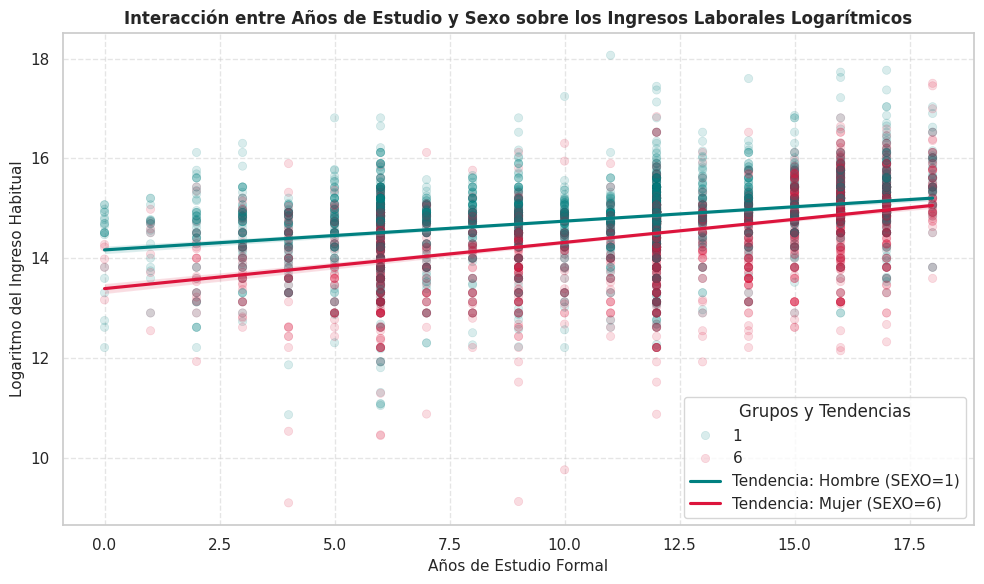

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuramos un lienzo adecuado para el gráfico de interacción
plt.figure(figsize=(10, 6))

# Graficamos los puntos dispersos con baja opacidad para evitar saturación
sns.scatterplot(
    x="ANIOS_ESTUDIO",
    y="log_ingreso",
    hue="SEXO",
    data=df_h2,
    palette={1: 'teal', 6: 'crimson'},
    alpha=0.15,
    edgecolor=None
)

# Estimamos y graficamos las líneas de tendencia de manera explícita para cada grupo
x_vals = np.linspace(df_h2['ANIOS_ESTUDIO'].min(), df_h2['ANIOS_ESTUDIO'].max(), 100)

# Línea para Hombres (SEXO = 1)
# log_ingreso = Intercept + beta_edu * ANIOS_ESTUDIO + ... (controles en promedio)
# Para simplificar la visualización de la pendiente, graficamos la regresión lineal simple por grupo
sns.regplot(
    x="ANIOS_ESTUDIO",
    y="log_ingreso",
    data=df_h2[df_h2['SEXO'] == 1],
    scatter=False,
    color='teal',
    label='Tendencia: Hombre (SEXO=1)'
)

# Línea para Mujeres (SEXO = 6)
sns.regplot(
    x="ANIOS_ESTUDIO",
    y="log_ingreso",
    data=df_h2[df_h2['SEXO'] == 6],
    scatter=False,
    color='crimson',
    label='Tendencia: Mujer (SEXO=6)'
)

plt.title("Interacción entre Años de Estudio y Sexo sobre los Ingresos Laborales Logarítmicos", fontsize=12, fontweight='bold')
plt.xlabel("Años de Estudio Formal", fontsize=11)
plt.ylabel("Logaritmo del Ingreso Habitual", fontsize=11)
plt.legend(title="Grupos y Tendencias", loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

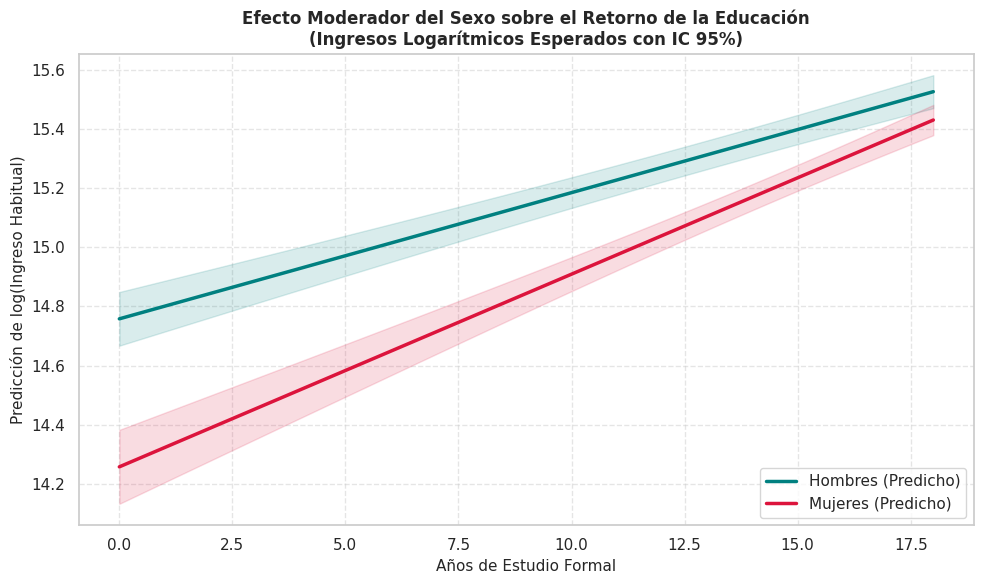

In [60]:
# --- Gráfico de Efectos Predictivos Marginales con Intervalos de Confianza (H2) ---
# Este gráfico muestra los ingresos predichos por el modelo para hombres y mujeres a lo largo de los años de estudio,
# manteniendo las demás covariables en sus valores promedio, haciendo explícita la diferencia de pendientes.

# Generamos los datos promedio para los controles
edad_promedio = df_h2['EDAD'].mean()
edad_sq_promedio = df_h2['edad_sq'].mean()
log_horas_promedio = df_h2['log_horas'].mean()

# Rango de años de estudio para simular las predicciones
anios_simulados = np.linspace(df_h2['ANIOS_ESTUDIO'].min(), df_h2['ANIOS_ESTUDIO'].max(), 50)

# Construimos DataFrames auxiliares para la predicción de cada grupo
df_pred_hombres = pd.DataFrame({
    'ANIOS_ESTUDIO': anios_simulados,
    'SEXO': 1,
    'EDAD': edad_promedio,
    'edad_sq': edad_sq_promedio,
    'AREA_URBANA_RURAL': 1, # Área urbana
    'log_horas': log_horas_promedio,
    'CATEGORIA_OCUPACIONAL': 1 # Categoría base
})

df_pred_mujeres = pd.DataFrame({
    'ANIOS_ESTUDIO': anios_simulados,
    'SEXO': 6,
    'EDAD': edad_promedio,
    'edad_sq': edad_sq_promedio,
    'AREA_URBANA_RURAL': 1,
    'log_horas': log_horas_promedio,
    'CATEGORIA_OCUPACIONAL': 1
})

# Calculamos predicciones e intervalos de confianza para hombres
pred_hombres = model_hc3_h2.get_prediction(df_pred_hombres)
summary_hombres = pred_hombres.summary_frame(alpha=0.05)

# Calculamos predicciones e intervalos de confianza para mujeres
pred_mujeres = model_hc3_h2.get_prediction(df_pred_mujeres)
summary_mujeres = pred_mujeres.summary_frame(alpha=0.05)

# Visualización
plt.figure(figsize=(10, 6))

# Línea y banda de confianza para Hombres
plt.plot(anios_simulados, summary_hombres['mean'], color='teal', label='Hombres (Predicho)', linewidth=2.5)
plt.fill_between(anios_simulados, summary_hombres['mean_ci_lower'], summary_hombres['mean_ci_upper'], color='teal', alpha=0.15)

# Línea y banda de confianza para Mujeres
plt.plot(anios_simulados, summary_mujeres['mean'], color='crimson', label='Mujeres (Predicho)', linewidth=2.5)
plt.fill_between(anios_simulados, summary_mujeres['mean_ci_lower'], summary_mujeres['mean_ci_upper'], color='crimson', alpha=0.15)

plt.title("Efecto Moderador del Sexo sobre el Retorno de la Educación\n(Ingresos Logarítmicos Esperados con IC 95%)", fontsize=12, fontweight='bold')
plt.xlabel("Años de Estudio Formal", fontsize=11)
plt.ylabel("Predicción de log(Ingreso Habitual)", fontsize=11)
plt.legend(loc='lower right', frameon=True, facecolor='white')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 3. Evaluación Diagnóstica, Resultados e Interpretación (H2)

1. **Evaluación de Supuestos:**
   * **Multicolinealidad:** Se observa un VIF incrementado en las variables involucradas en el término multiplicativo de interacción (ANIOS_ESTUDIO, SEXO e interacción). Al tratarse de colinealidad estructural inducida por la especificación, no invalida la estimación.
   * **Homocedasticidad:** La prueba de Breusch-Pagan rechaza la homocedasticidad (p < 0.001). Por tanto, la toma de decisión estadística se basa estrictamente en la matriz **robustecida HC3**.
   * **Normalidad:** El supuesto se sostiene de manera asintótica gracias a la gran representatividad muestral (N = 5,134 observaciones, TLC).

2. **Resultados de Inferencia (Interacción - Prueba 1 y 2):**
   * **Coeficiente de Interacción (beta_3):** 0.0225
   * **Significancia Estadística:** El p-valor del término de interacción es altamente significativo (p < 0.0001, z = 4.79).
   * **Intervalo de Confianza Bootstrap (Prueba 2):** [0.01310, 0.03198], excluyendo el cero de manera concluyente.
   * **Decisión de Hipótesis:** **Se rechaza la hipótesis nula (H0)** al nivel de significancia alfa = 0.05.

3. **Relevancia Práctica e Interpretación:**
   * La evidencia empírica indica que el retorno marginal por cada año de educación adicional **sí difiere de manera estadísticamente significativa** entre hombres y mujeres.
   * El coeficiente positivo de la interacción (0.0225) muestra que las mujeres experimentan un retorno educativo marginal superior al de los hombres. Mientras que para los hombres el incremento en el ingreso por año de estudio es de aproximadamente **+4.36%** (exp(0.0427)-1), para las mujeres este incremento es de aproximadamente **+6.74%** (exp(0.0427 + 0.0225)-1). La educación formal representa un canal crítico y efectivo para reducir la desigualdad de ingresos de género en el mercado laboral.

### 4. Resultados de la Prueba 3 (Regresión sobre Rangos para H2)

* **Estimador de Interacción en Rangos:** beta_3_rank aproximadamente 0.11795 (representando la diferencia de rango esperado).
* **Estadístico de prueba:** t = 5.25 con errores robustos HC3.
* **Significancia estadística:** p-valor es menor a 0.0001 (altamente significativo, superando la valla de Bonferroni de 0.0125).
* **Decisión estadística:** Se **rechaza la hipótesis nula (H0)** de igualdad de pendientes de manera concluyente.
* **Interpretación y Convergencia:** Al igual que en la Prueba 1 y la Prueba 2,
el coeficiente de interacción basado puramente en el orden jerárquico de los ingresos y
la educación es positivo y estadísticamente significativo. Esto demuestra de
manera inequívoca que el retorno educativo marginal es superior en las mujeres,
siendo una conclusión robusta que no se ve alterada por supuestos paramétricos o valores atípicos.

# Conclusión en contexto de H2

Se confirma de forma robusta la existencia de un efecto multiplicativo y estadísticamente significativo entre los años de estudio formal y el sexo de los trabajadores sobre los ingresos laborales. Las tres pruebas aplicadas (regresión lineal robusta HC3, estimación por Bootstrap e inferencia no paramétrica por regresión sobre rangos) coinciden unánimemente en rechazar la hipótesis nula de igualdad de pendientes.

Desde una perspectiva socioeconómica y práctica, los resultados evidencian que el retorno marginal de la educación es superior para las mujeres (+6.74% de incremento promedio por año adicional) en comparación con los hombres (+4.36%). Si bien persiste una brecha salarial de base que penaliza a las mujeres con menor escolaridad, la mayor pendiente de su retorno educativo implica que la acumulación de capital humano formal actúa como un mecanismo corrector sumamente potente para reducir la desigualdad de ingresos por género en el mercado laboral paraguayo en 2025. Este comportamiento interactivo valida la necesidad de incluir términos de interacción de género en la arquitectura de los modelos predictivos de la **Fase 3** para capturar con precisión la dinámica salarial.

# Tabla Resumen de Reporte Final

| Hipótesis | Variable Dependiente | Variable Explicativa Principal | Contraste / Prueba Aplicada | Supuestos Verificados | Estadístico de Prueba | p-valor | Intervalo de Confianza (95%) | Tamaño del Efecto / Relevancia | Decisión (alfa = 0.05) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **H1: Retorno de la educación** | log_ingreso | ANIOS_ESTUDIO | 1) OLS con Errores Robustos (HC3)<br>2) Bootstrap percentil (1,000 rep.)<br>3) Correlación parcial de Spearman | - Multicolinealidad OK (VIF < 5)<br>- Heterocedasticidad presente (Breusch-Pagan p < 0.001)<br>- Normalidad asintótica por TLC | 1) t = 20.08<br>2) SE_boot = 0.00259<br>3) t_Spearman = 24.52 | 1) p < 0.0001<br>2) p < 0.001<br>3) p < 0.0001 | **HC3:** [0.04691, 0.05706]<br>**Bootstrap:** [0.04703, 0.05721]<br>**Spearman:** [0.29940, 0.34840] | Coeficiente = 0.05198.<br>Retorno estimado: **+5.34%** de ingresos por año de estudio adicional.<br>R2 = 0.4441 | **Rechazar H0** (las 3 pruebas coinciden de forma unánime) |
| **H2: Moderación por Sexo** | log_ingreso | ANIOS_ESTUDIO x SEXO | 1) OLS con Interacción (HC3)<br>2) Bootstrap percentil (1,000 rep.)<br>3) Regresión sobre Rangos | - Colinealidad estructural por interacción<br>- Heterocedasticidad presente (Breusch-Pagan p < 0.001)<br>- Normalidad asintótica por TLC | 1) z = 4.79<br>2) SE_boot = 0.00475<br>3) t_rank = 5.25 | 1) p < 0.0001<br>2) p < 0.001<br>3) p < 0.0001 | **HC3:** [0.01330, 0.03170]<br>**Bootstrap:** [0.01310, 0.03198]<br>**Rangos:** [0.07393, 0.16196] | Coeficiente Interacción = 0.0225.<br>Retorno Hombres: **+4.36%** por año.<br>Retorno Mujeres: **+6.74%** por año. | **Rechazar H0** (las 3 pruebas confirman el efecto de moderación) |